Try out of GRU setup of PyTorch for a simple timeseries prediction of Temperature data from ERA5

Peter Resch, 20.5.

also looked here for inspiration: https://github.com/julianstefinovic/era5-precipitation-modelling

In [19]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np

from sklearn.manifold import TSNE
import seaborn as sns

from sklearn import metrics
import sklearn as sk

import torch as pt

import scipy

rSeed=42

SavePlots = False

## Loading Data

In [20]:
#from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=download
# ERA5 single levels time series
filename="../common_tryout_datasets/single_point_timeseries_t2m.nc"

import netCDF4
import xarray as xr

# Open the NetCDF files using xarray
temp_ds = xr.open_dataset(filename)

# Check the available variables
print("Temperature data variables:", temp_ds.variables)

Temperature data variables: Frozen({'t2m': <xarray.Variable (valid_time: 757104)> Size: 3MB
[757104 values with dtype=float32]
Attributes: (12/30)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           t2m
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_typeOfLevel:                         surface
    GRIB_units:                               K
    long_name:                                2 metre temperature
    standard_name:                            unknown
    units:                                    K, 'latitude': <xarray.Variable ()> Size: 8B
[1 values with dtype=float64]
Attributes:
    long_name:         latitude
    standard_name:     latitude
    stored_direction:  decreasing


## Prepare Dataset

In [21]:
temp_df=temp_ds.to_dataframe()
temp_df.drop(columns=["longitude","latitude"], inplace=True)


n_input_features=temp_df.shape[1]
print("Number of input features:", n_input_features)

temp_df.head()

Number of input features: 1


,t2m
valid_time,
1940-01-01 00:00:00,295.022522
1940-01-01 01:00:00,294.292114
1940-01-01 02:00:00,293.417786
1940-01-01 03:00:00,292.723022
1940-01-01 04:00:00,291.561798


In [22]:
temp_df["t2m"]

valid_time
1940-01-01 00:00:00    295.022522
1940-01-01 01:00:00    294.292114
1940-01-01 02:00:00    293.417786
1940-01-01 03:00:00    292.723022
1940-01-01 04:00:00    291.561798
                          ...    
2026-05-14 19:00:00    305.069275
2026-05-14 20:00:00    303.158661
2026-05-14 21:00:00    301.268616
2026-05-14 22:00:00    300.041595
2026-05-14 23:00:00    299.063721
Name: t2m, Length: 757104, dtype: float32

In [23]:
temp_df["t2m"][0:2]

valid_time
1940-01-01 00:00:00    295.022522
1940-01-01 01:00:00    294.292114
Name: t2m, dtype: float32

In [24]:
temp_df[0:2]["t2m"]

valid_time
1940-01-01 00:00:00    295.022522
1940-01-01 01:00:00    294.292114
Name: t2m, dtype: float32

In [25]:
temp_df[0:2]

,t2m
valid_time,
1940-01-01 00:00:00,295.022522
1940-01-01 01:00:00,294.292114


In [26]:
temp_df.loc["1940-01-01 00:00:00"]

t2m    295.022522
Name: 1940-01-01 00:00:00, dtype: float32

In [27]:
temp_df.iloc[0:2]

,t2m
valid_time,
1940-01-01 00:00:00,295.022522
1940-01-01 01:00:00,294.292114


In [28]:
temp_df.iloc[0:2].values

array([[295.02252],
       [294.2921 ]], dtype=float32)

In [29]:
dataset=temp_df.values


# Normalize the dataset
scaler = sk.preprocessing.StandardScaler()
dataset = scaler.fit_transform(dataset)#!!!!!!!!!!!!!!!also fitting on future data, but this is just a tryout, so it is not a problem for now. In the final version, I will fit only on the training data and then transform the validation and validate data using the same scaler.
dataset.shape

(757104, 1)

((30284, 24, 1), (30284, 1, 1))

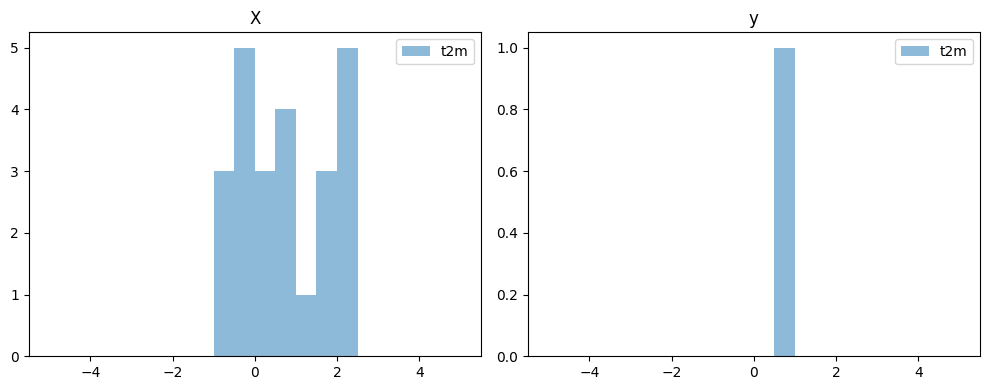

In [43]:
# Split the dataset into input (X) and output (y) variables
forecast_history = 24
forecast_horizon = 1#univariate forecasting, so only t2m is forecasted, but the input can contain multiple features, such as longitude and latitude. In the final version, I will also try multivariate forecasting, where multiple features are forecasted at the same time.
forecast_data_size = forecast_history + forecast_horizon

total_data_len = dataset.shape[0]

X_array = []
y_array = []

for i in range(0, total_data_len-forecast_data_size, forecast_data_size):
    X = dataset[i:i+forecast_history,:]
    y = dataset[i+forecast_history:i+forecast_history+forecast_horizon,:]

    X_array.append(X)
    y_array.append(y)

X_array = np.array(X_array)
y_array = np.array(y_array)

#print(f"i={i}, X={X}, y={y}")
#print(f"X_array: \n{X_array}\n")
#print(f"X_array: \n{X_array[0]}\n")
#print(f"X_array: \n{X_array[0][:,0]}\n")



fig,ax=plt.subplots(1,2,figsize=(10,4))

ax[0].hist(X[:,0], bins=20,range=(-5,5),label="t2m",alpha=0.5)
#ax[0].hist(X[:,1], bins=20,range=(-5,5),label="longitude",alpha=0.5)
ax[0].legend()
ax[1].hist(y[:,0], bins=20,range=(-5,5),label="t2m",alpha=0.5)
#ax[1].hist(y[:,1], bins=20,range=(-5,5),label="longitude", alpha=0.5)
ax[1].legend()
ax[0].set_title("X")
ax[1].set_title("y")
plt.tight_layout()

X_array.shape, y_array.shape

In [44]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return len(self.input)


#Split the data into training and validateing sets
X_array, X_test, y_array, y_test = train_test_split(X_array, y_array, test_size=0.1, random_state=rSeed)


X_train, X_validate, y_train, y_validate = train_test_split(X_array, y_array, test_size=0.2, random_state=rSeed)
len(X_train),X_train[0].shape,len(X_array),X_array[0].shape

(21804, (24, 1), 27255, (24, 1))

In [46]:
def make_loader(X, y,batch_size):
    X_tensor=torch.FloatTensor(np.array(X))
    print(f"X_tensor shape: {X_tensor.shape}")
    y_tensor=torch.FloatTensor(np.array(y))
    set = MyDataset(X_tensor, y_tensor)
    loader = DataLoader(set, batch_size=batch_size)
    return loader


trainloader = make_loader(X_train, y_train, batch_size=200)
validateloader = make_loader(X_validate, y_validate, batch_size=200)
testloader = make_loader(X_test, y_test, batch_size=200)

X_tensor shape: torch.Size([21804, 24, 1])
X_tensor shape: torch.Size([5451, 24, 1])
X_tensor shape: torch.Size([3029, 24, 1])


In [47]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


class myGRU(nn.Module):
    def __init__(self,hidden_size=8):
        super().__init__()
        self.gru = nn.GRU(input_size=n_input_features,hidden_size=hidden_size, num_layers=1,dropout=0,batch_first=True)
        self.linear = nn.Linear(hidden_size, n_input_features) # univariate output, so output size is 1

    def forward(self, x):
        #print("in NeuralNetwork.forward")
        #print(x.shape)
        x,y = self.gru(x)
        #print(x.shape,y.shape)
        x = x[:,-1,:].view(x.shape[0], 1,x.shape[2])#last hidden state
        #print(x.shape)
        x=self.linear(x)
        #print(x.shape)
        return x



gru_model=myGRU().to(device)
print(gru_model)

# Loss function and optimizer
loss_fcn = nn.MSELoss()
optimizer = AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)

Using cpu device
myGRU(
  (gru): GRU(1, 8, batch_first=True)
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


In [48]:
def train(dataloader, model, loss_fn, optimizer,device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        #print(X.shape, y.shape)
        X, y = X.to(device), y.to(device)
        #print(X.shape, y.shape)

        # Compute prediction error
        pred = model(X)#.squeeze()
        #print(pred)#.shape)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def validate(dataloader, model, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    validate_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            validate_loss += loss_fn(logits, y).item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == y).float().sum().item()
    validate_loss /= num_batches
    correct /= size
    print(f"validate Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {validate_loss:>8f} \n")



In [49]:
trainloader.dataset.input.shape, trainloader.dataset.truth.shape

(torch.Size([21804, 24, 1]), torch.Size([21804, 1, 1]))

In [50]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainloader, gru_model, loss_fcn, optimizer,device)
    validate(validateloader, gru_model, loss_fcn,device)
print("Done!")

Epoch 1
-------------------------------
loss: 0.830188  [  200/21804]


loss: 0.836906  [ 2200/21804]
loss: 0.784420  [ 4200/21804]
loss: 0.673817  [ 6200/21804]
loss: 0.658080  [ 8200/21804]
loss: 0.623219  [10200/21804]
loss: 0.509122  [12200/21804]
loss: 0.478426  [14200/21804]
loss: 0.506984  [16200/21804]
loss: 0.360752  [18200/21804]
loss: 0.308869  [20200/21804]
validate Error: 
 Accuracy: 0.0%, Avg loss: 0.341348 

Epoch 2
-------------------------------
loss: 0.306255  [  200/21804]
loss: 0.329475  [ 2200/21804]
loss: 0.322186  [ 4200/21804]
loss: 0.266545  [ 6200/21804]
loss: 0.230649  [ 8200/21804]
loss: 0.247492  [10200/21804]
loss: 0.226946  [12200/21804]
loss: 0.201205  [14200/21804]
loss: 0.192310  [16200/21804]
loss: 0.165345  [18200/21804]
loss: 0.150849  [20200/21804]
validate Error: 
 Accuracy: 0.0%, Avg loss: 0.153891 

Done!


In [ ]:
#finding how many dataseries were not used for training and validating


In [ ]:
# Make predictions:
with torch.no_grad():
    trainPredict = gru_model(trainX).numpy()
    validatePredict = gru_model(validateX).numpy()

# Invert predictions:
trainPredict = scaler.inverse_transform(trainPredict)
trainY_inv = scaler.inverse_transform([trainY.numpy()])
validatePredict = scaler.inverse_transform(validatePredict)
validateY_inv = scaler.inverse_transform([validateY.numpy()])

# Calculate root mean squared error:
trainScore = math.sqrt(mean_squared_error(trainY_inv[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
validateScore = math.sqrt(mean_squared_error(validateY_inv[0], validatePredict[:,0]))
print('validate Score: %.2f RMSE' % (validateScore))

# Shift train predictions for plotting:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

# Shift validate predictions for plotting:
validatePredictPlot = np.empty_like(dataset)
validatePredictPlot[:, :] = np.nan
validatePredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = validatePredict

# Plot baseline and predictions:
plt.plot(scaler.inverse_transform(dataset), label="Data")
plt.plot(trainPredictPlot, label="Training predictions")
plt.plot(testPredictPlot, label="validateing predictions")
plt.legend()
plt.show()

## Tryout Section

In [ ]:
Xtry,ytry=next(iter(trainloader))
print(Xtry.shape)#, ytry.shape)

print(Xtry[0,:,:].shape)
print(Xtry.shape[0])

print(Xtry[:,-1,:].view(Xtry.shape[0], 1,Xtry.shape[2]).shape)
#logits=gru_model(Xtry)

#logits.shape

torch.Size([200, 24, 1])
torch.Size([24, 1])
200
torch.Size([200, 1, 1])


In [ ]:
lstm = nn.LSTM(3, 7)  # Input dim is 3, output dim is 3
inputs = [torch.randn(1, 3) for _ in range(5)]  # make a sequence of length 5

print("inputs",inputs)

# initialize the hidden state.
hidden = (torch.randn(1, 1, 7),
          torch.randn(1, 1, 7))

print("hidden",hidden)
print("\n")

for i in inputs:
    # Step through the sequence one element at a time.
    # after each step, hidden contains the hidden state.
    print("i",i)
    print("i.view",i.view(1, 1, -1))
    out, hidden = lstm(i.view(1, 1, -1))#, hidden)
    print("out",out)
    print("hidden",hidden)
    print("\n")

# alternatively, we can do the entire sequence all at once.
# the first value returned by LSTM is all of the hidden states throughout
# the sequence. the second is just the most recent hidden state
# (compare the last slice of "out" with "hidden" below, they are the same)
# The reason for this is that:
# "out" will give you access to all hidden states in the sequence
# "hidden" will allow you to continue the sequence and backpropagate,
# by passing it as an argument  to the lstm at a later time
# Add the extra 2nd dimension
inputs = torch.cat(inputs).view(len(inputs), 1, -1)
hidden = (torch.randn(1, 1, 7), torch.randn(1, 1, 7))  # clean out hidden state
out, hidden = lstm(inputs, hidden)
print("inputs",inputs)
print("out",out)
#print(out)
print(hidden)

inputs [tensor([[ 1.0954, -1.1414, -1.1992]]), tensor([[-1.1102, -2.2122, -2.3529]]), tensor([[-0.3800, -0.5648,  0.4184]]), tensor([[0.1016, 0.3898, 0.3354]]), tensor([[ 0.7101,  1.1947, -1.0615]])]
hidden (tensor([[[-0.8668, -0.4601, -0.3616,  2.6038, -0.7154,  0.3641,  0.4614]]]), tensor([[[ 0.0893,  0.3040, -1.2753, -1.1254, -1.1500,  0.0124,  1.0255]]]))


i tensor([[ 1.0954, -1.1414, -1.1992]])
i.view tensor([[[ 1.0954, -1.1414, -1.1992]]])
out tensor([[[ 0.0268,  0.1358,  0.1985,  0.0165, -0.0325,  0.2752,  0.0967]]],
       grad_fn=<MkldnnRnnLayerBackward0>)
hidden (tensor([[[ 0.0268,  0.1358,  0.1985,  0.0165, -0.0325,  0.2752,  0.0967]]],
       grad_fn=<StackBackward0>), tensor([[[ 0.0558,  0.2905,  0.2948,  0.0262, -0.0851,  0.5459,  0.3242]]],
       grad_fn=<StackBackward0>))


i tensor([[-1.1102, -2.2122, -2.3529]])
i.view tensor([[[-1.1102, -2.2122, -2.3529]]])
out tensor([[[-0.1818,  0.1972,  0.3436,  0.0867, -0.0491,  0.0951,  0.2367]]],
       grad_fn=<MkldnnRnnLayer